# Explainability Demo -- COMPAS recidivism data

Model-level: interpretable models, feature importance, PDP | Prediction-level: LIME, SHAP, counterfactuals | Data-level: prototypes

In [5]:
%pip install shap lime dice-ml scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

## Data -- COMPAS from ProPublica, predict `is_recid`

In [7]:
# Load COMPAS dataset from ProPublica
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(url)
print(f"Raw dataset: {raw.shape[0]} rows, {raw.shape[1]} columns")
raw.head()

Raw dataset: 7214 rows, 53 columns


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [8]:
# Preprocessing: select features, encode categoricals, split
df = raw[["age", "sex", "race", "juv_fel_count", "juv_misd_count", "juv_other_count",
          "priors_count", "c_charge_degree", "is_recid",
          "c_jail_in", "c_jail_out"]].dropna()

# Compute days in jail
df = df.copy()
df["days_in_jail"] = (pd.to_datetime(df["c_jail_out"]) - pd.to_datetime(df["c_jail_in"])).dt.days
df = df.drop(columns=["c_jail_in", "c_jail_out"])

# Encode categorical features
label_encoders = {}
for col in ["sex", "race", "c_charge_degree"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

feature_names = [c for c in df.columns if c != "is_recid"]
X = df[feature_names]
y = df["is_recid"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaled versions for models that need it (logreg, NN)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features: {feature_names}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Recidivism rate: {y.mean():.1%}")
X_train.head()

Features: ['age', 'sex', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree', 'days_in_jail']
Train: 5525, Test: 1382
Recidivism rate: 49.3%


,age,sex,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,days_in_jail
3593,24,1,0,0,0,0,7,0,68
1964,48,1,0,0,0,0,5,0,242
5428,46,1,0,0,0,0,3,0,35
1009,60,1,2,0,0,0,1,0,0
4727,32,1,0,0,0,0,3,0,0


Gradient Boosting: 100 trees, each up to depth 4
Accuracy: 0.677
Total nodes across all trees: 2836



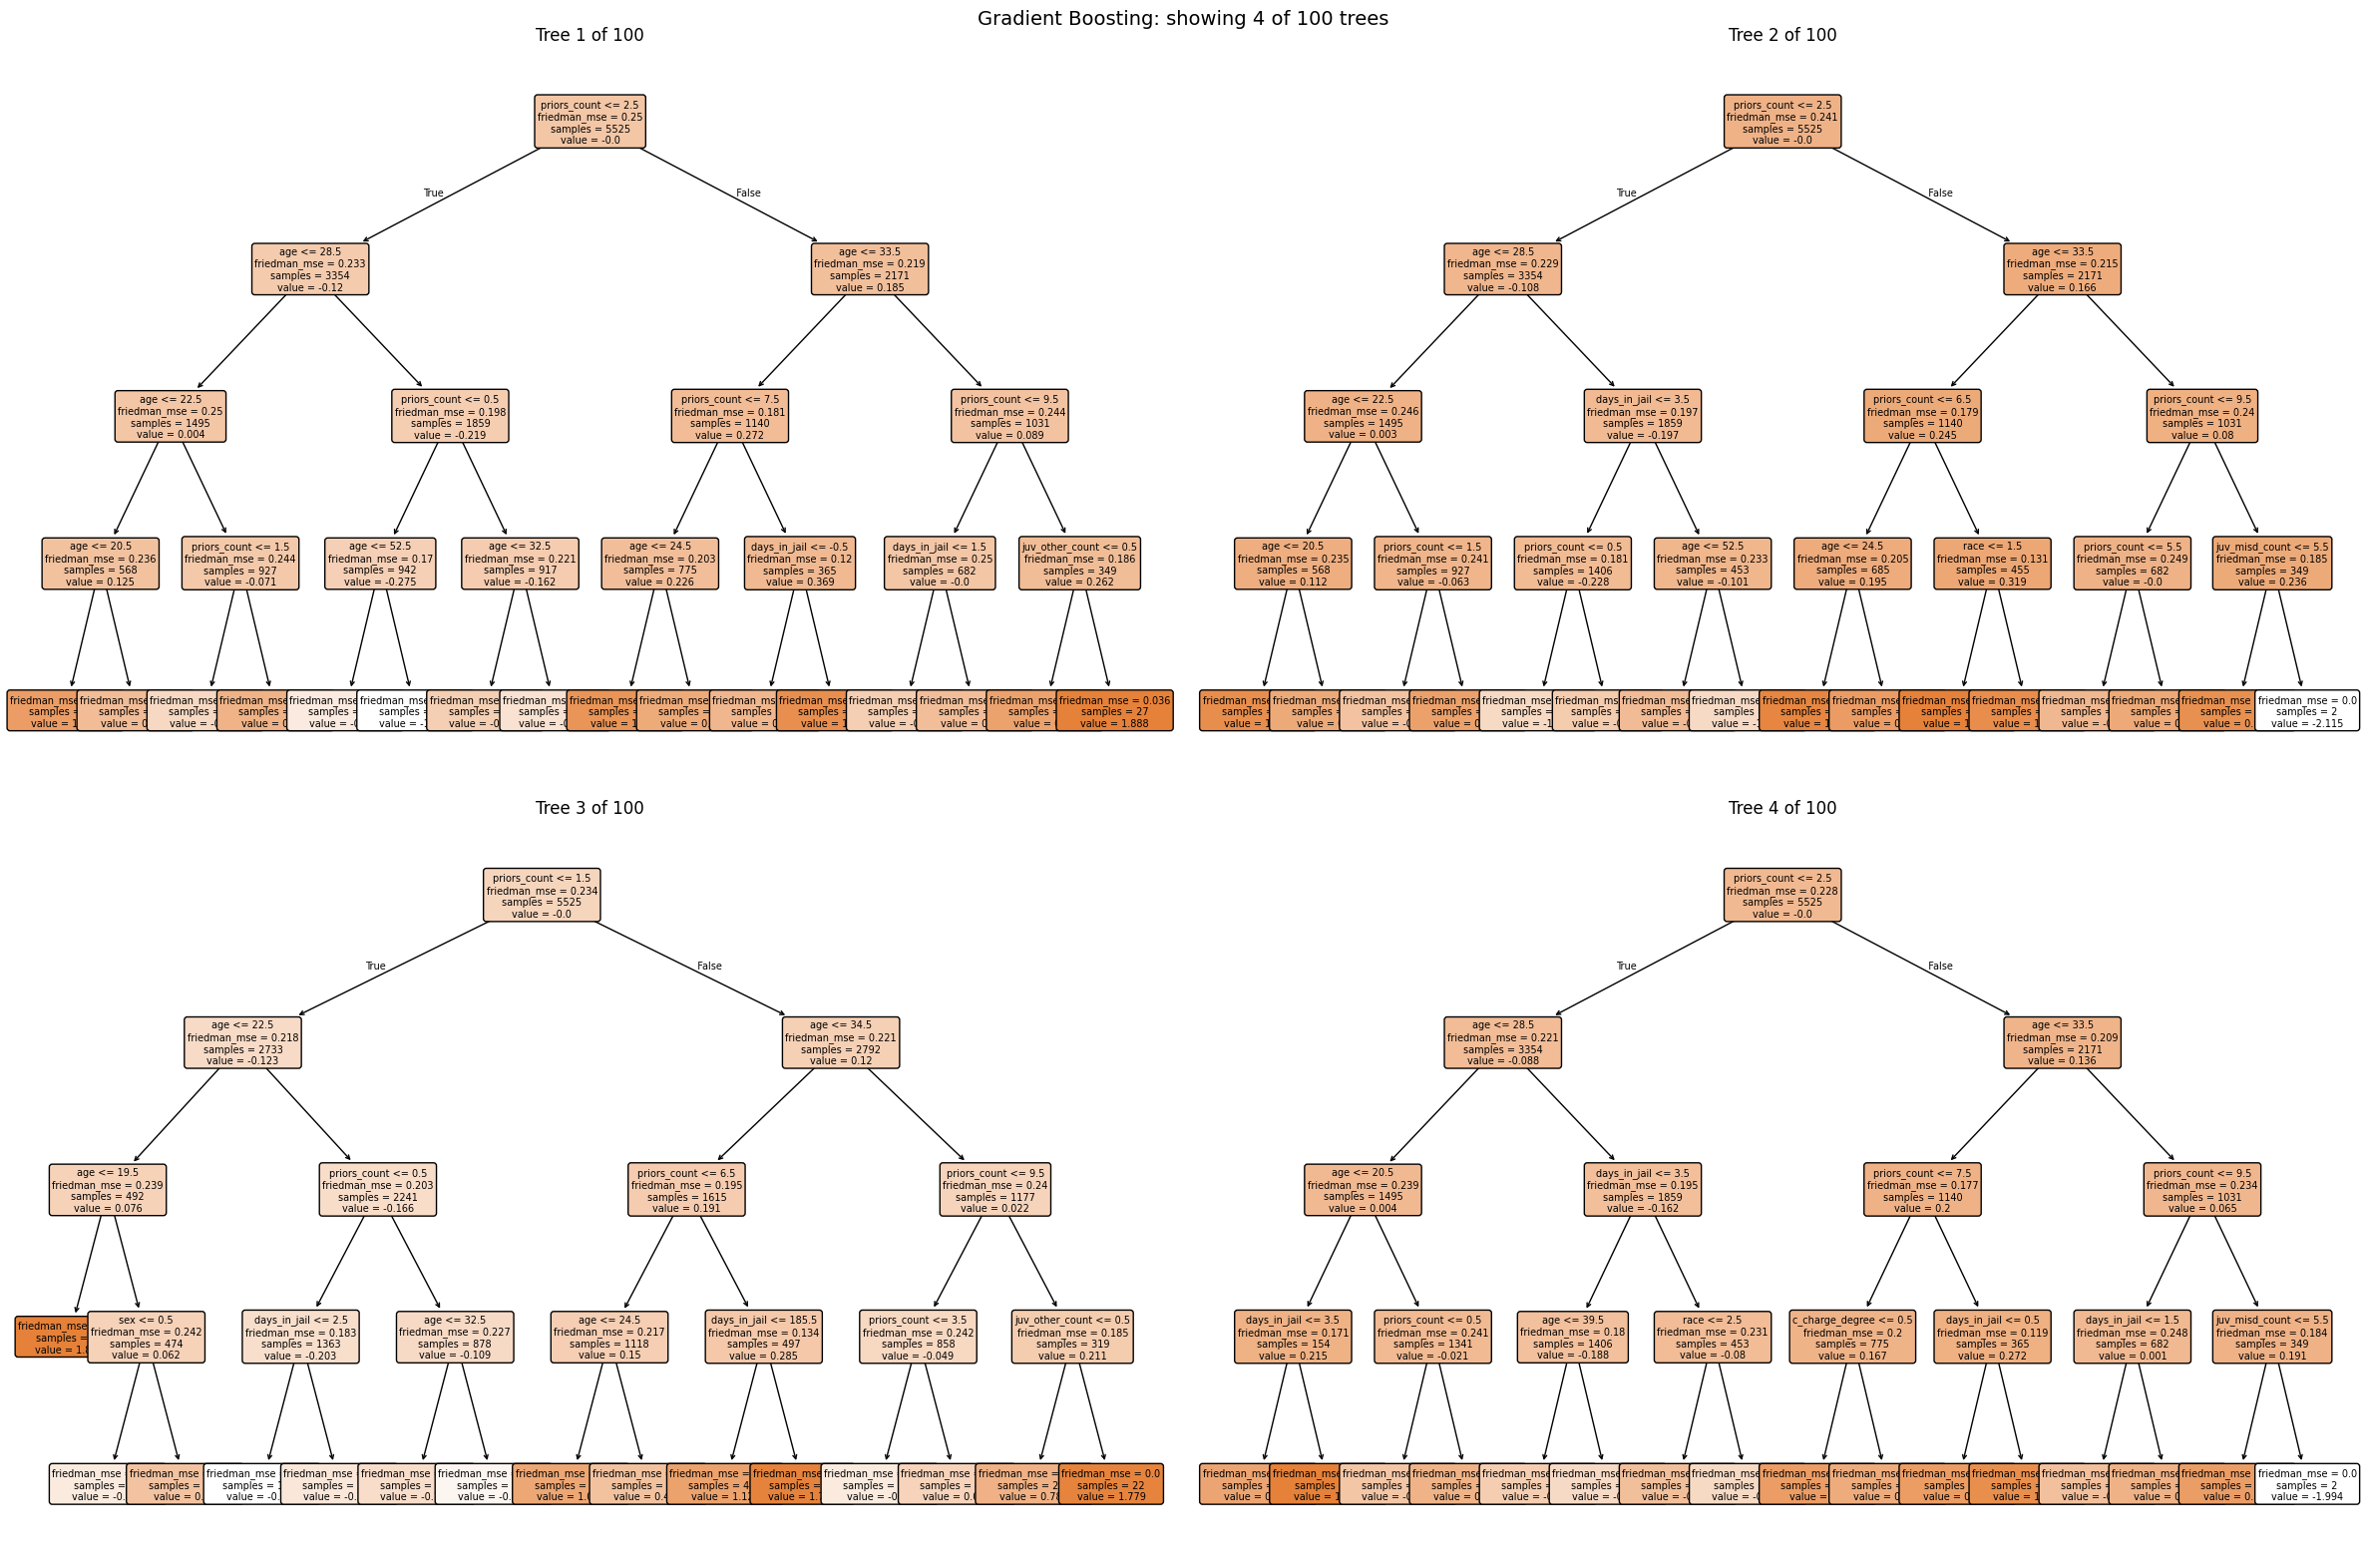

In [9]:
# Train a Gradient Boosting model and visualize its internals as trees
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import plot_tree

gbm_demo = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
gbm_demo.fit(X_train, y_train)

print(f"Gradient Boosting: {gbm_demo.n_estimators} trees, each up to depth {gbm_demo.max_depth}")
print(f"Accuracy: {accuracy_score(y_test, gbm_demo.predict(X_test)):.3f}")
print(f"Total nodes across all trees: {sum(t[0].tree_.node_count for t in gbm_demo.estimators_)}\n")

# Plot first 4 trees out of 100
fig, axes = plt.subplots(2, 2, figsize=(24, 16))
for i, ax in enumerate(axes.flatten()):
    plot_tree(gbm_demo.estimators_[i, 0], feature_names=feature_names,
              filled=True, rounded=True, ax=ax, fontsize=7)
    ax.set_title(f"Tree {i+1} of {gbm_demo.n_estimators}")

fig.suptitle(f"Gradient Boosting: showing 4 of {gbm_demo.n_estimators} trees", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Train a simple neural network and print its internals
from sklearn.neural_network import MLPClassifier

nn_demo = MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=500, random_state=42)
nn_demo.fit(X_train_scaled, y_train)

print(f"Neural Network: layers {nn_demo.hidden_layer_sizes}, activation={nn_demo.activation}")
print(f"Accuracy: {accuracy_score(y_test, nn_demo.predict(X_test_scaled)):.3f}\n")

# Print all weight matrices and biases
total_params = 0
for i, (W, b) in enumerate(zip(nn_demo.coefs_, nn_demo.intercepts_)):
    total_params += W.size + b.size
    print(f"--- Layer {i+1}: weight matrix shape {W.shape}, bias shape {b.shape} ---")
    print(f"  Weights:\n{np.round(W, 4)}")
    print(f"  Biases: {np.round(b, 4).tolist()}")
    print()

print(f"Total parameters: {total_params}")
print(f"Each prediction requires multiplying inputs through all {len(nn_demo.coefs_)} weight matrices.")

Neural Network: layers (64, 32, 16), activation=relu
Accuracy: 0.653

--- Layer 1: weight matrix shape (9, 64), bias shape (64,) ---
  Weights:
[[ 1.896e-01  3.760e-01  1.158e-01 -1.175e-01 -3.782e-01 -2.045e-01
  -4.660e-01  4.868e-01  8.680e-02  1.347e-01 -3.056e-01  3.492e-01
   3.518e-01 -3.314e-01 -8.310e-02 -2.932e-01 -1.916e-01 -3.020e-02
   1.860e-02 -7.110e-02 -1.320e-02 -4.803e-01 -4.256e-01 -1.167e-01
  -2.538e-01  2.838e-01 -2.659e-01  9.850e-02  3.374e-01 -4.916e-01
  -3.730e-02 -4.014e-01 -5.369e-01  2.883e-01  3.249e-01  9.170e-02
  -8.960e-02 -4.469e-01  1.675e-01  4.700e-02 -1.585e-01  1.520e-02
  -4.131e-01  4.093e-01 -9.260e-02  1.388e-01 -2.027e-01 -3.940e-02
  -7.300e-02 -1.893e-01  2.953e-01  3.305e-01  1.877e-01  2.685e-01
   9.320e-02  2.639e-01 -2.661e-01 -2.712e-01 -4.995e-01 -9.360e-02
  -1.468e-01 -3.996e-01  4.108e-01 -1.440e-02]
 [-1.256e-01 -7.850e-02 -3.441e-01  1.861e-01 -2.412e-01  3.009e-01
   1.110e-01 -9.870e-02 -3.089e-01  1.299e-01 -6.730e-02  4.7

## 1. Interpretable models -- logreg coefficients, shallow tree, accuracy tradeoff vs GBM

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Shallow Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Black-box: Gradient Boosting
gbm = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
gbm.fit(X_train, y_train)

# Compare accuracy
models = {"Logistic Regression": lr, "Decision Tree (depth=4)": dt, "Gradient Boosting": gbm}
for name, model in models.items():
    X_eval = X_test_scaled if name == "Logistic Regression" else X_test
    acc = accuracy_score(y_test, model.predict(X_eval))
    print(f"{name:30s} Accuracy: {acc:.3f}")

Logistic Regression            Accuracy: 0.679
Decision Tree (depth=4)        Accuracy: 0.670
Gradient Boosting              Accuracy: 0.677


In [12]:
# Print logistic regression as a formula
terms = [f"{coef:+.4f}*{name}" for coef, name in zip(lr.coef_[0], feature_names)]
formula = f"P(recid) = sigmoid({lr.intercept_[0]:+.4f} " + " ".join(terms) + ")"
print(formula)

P(recid) = sigmoid(+0.0005 -0.4923*age +0.0840*sex -0.0829*race +0.1036*juv_fel_count +0.0063*juv_misd_count +0.1428*juv_other_count +0.7749*priors_count -0.0751*c_charge_degree +0.1420*days_in_jail)


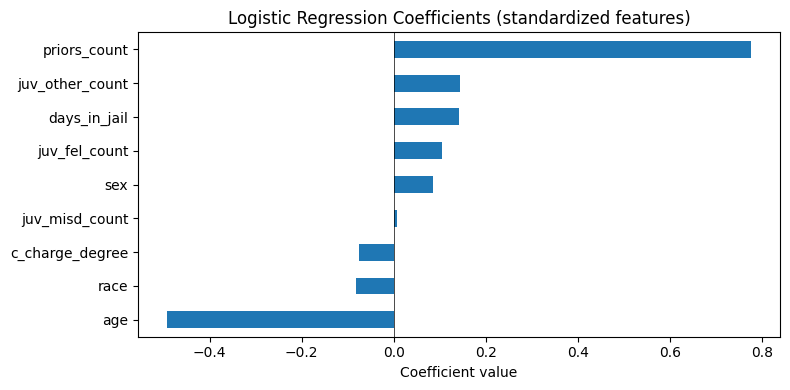

In [13]:
# Logistic regression coefficients -- directly interpretable
coefs = pd.Series(lr.coef_[0], index=feature_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
coefs.plot.barh(ax=ax)
ax.set_title("Logistic Regression Coefficients (standardized features)")
ax.set_xlabel("Coefficient value")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

Decision Tree (depth=4, leaves=16):
|--- priors_count <= 2.50
|   |--- age <= 28.50
|   |   |--- age <= 22.50
|   |   |   |--- age <= 20.50
|   |   |   |   |--- weights: [35.00, 119.00] class: 1
|   |   |   |--- age >  20.50
|   |   |   |   |--- weights: [183.00, 231.00] class: 1
|   |   |--- age >  22.50
|   |   |   |--- priors_count <= 1.50
|   |   |   |   |--- weights: [461.00, 263.00] class: 0
|   |   |   |--- priors_count >  1.50
|   |   |   |   |--- weights: [76.00, 127.00] class: 1
|   |--- age >  28.50
|   |   |--- priors_count <= 0.50
|   |   |   |--- age <= 52.50
|   |   |   |   |--- weights: [567.00, 184.00] class: 0
|   |   |   |--- age >  52.50
|   |   |   |   |--- weights: [171.00, 20.00] class: 0
|   |   |--- priors_count >  0.50
|   |   |   |--- age <= 32.50
|   |   |   |   |--- weights: [117.00, 89.00] class: 0
|   |   |   |--- age >  32.50
|   |   |   |   |--- weights: [498.00, 213.00] class: 0
|--- priors_count >  2.50
|   |--- age <= 33.50
|   |   |--- priors_count 

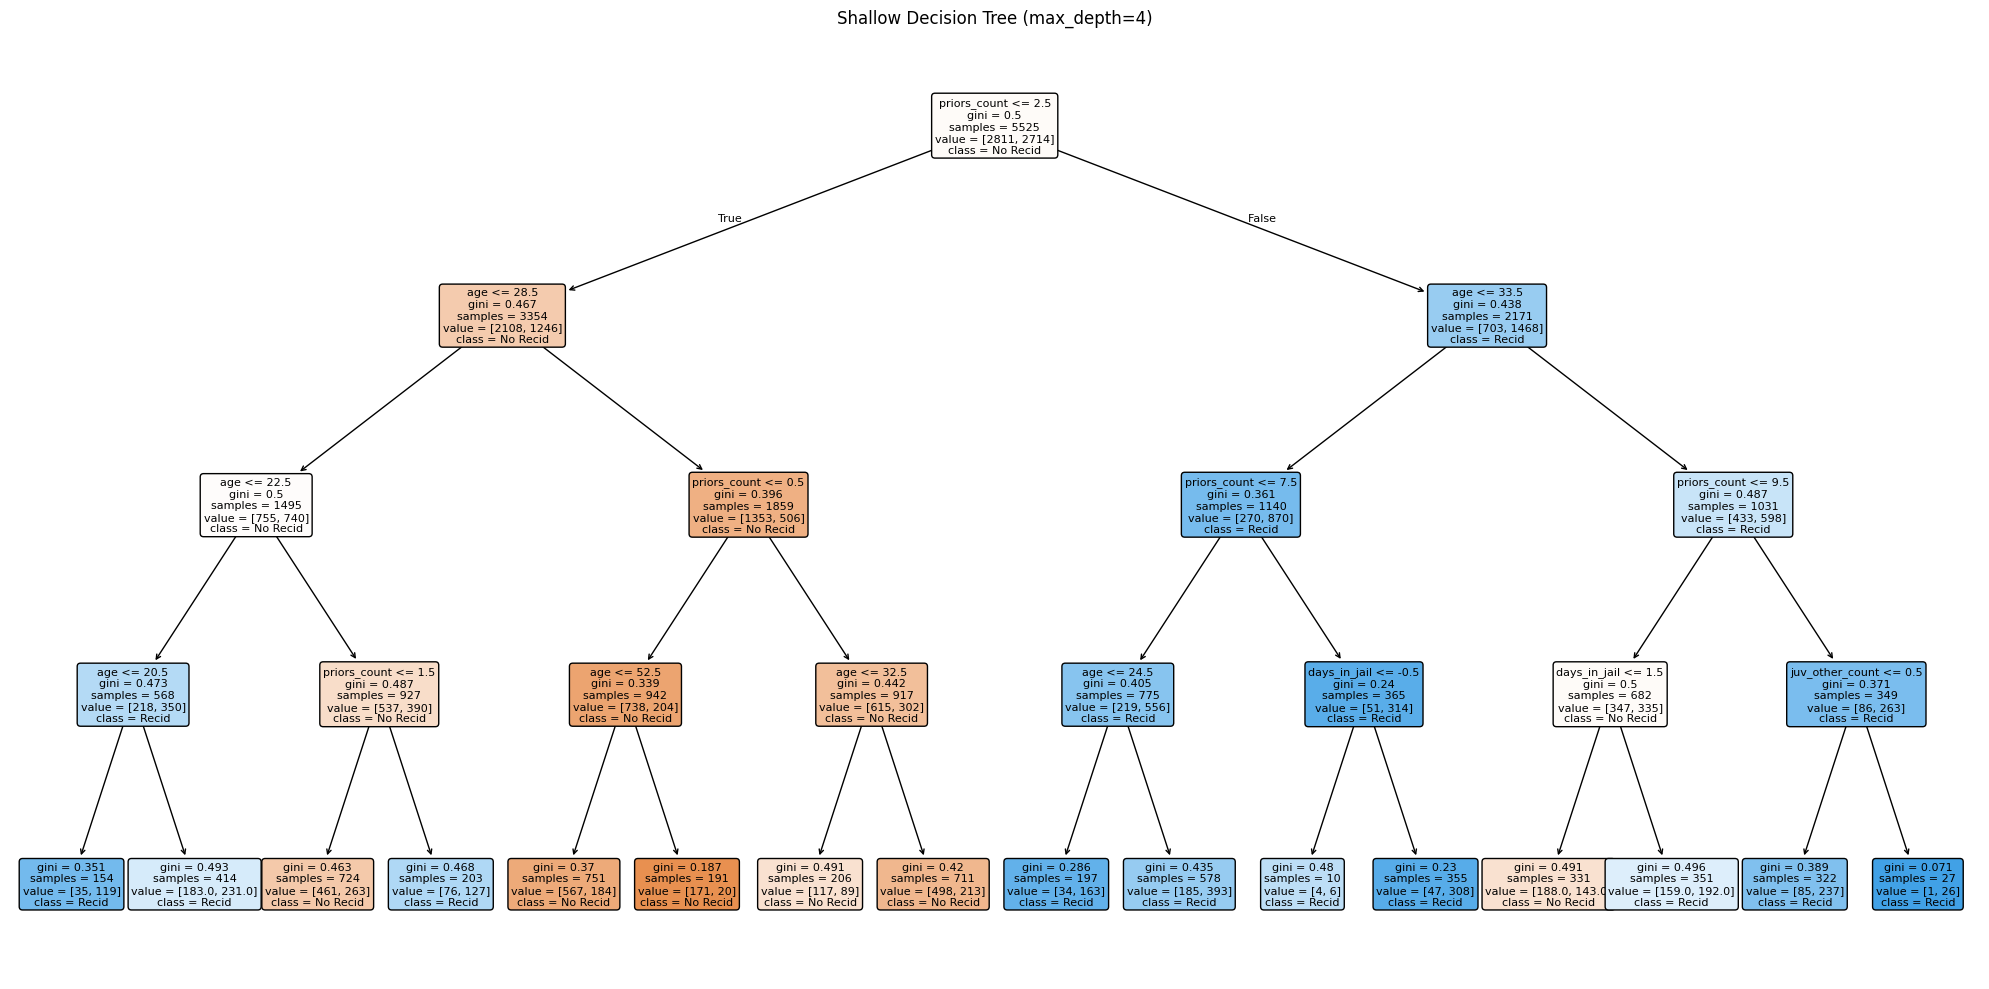

In [14]:
from sklearn.tree import export_text

tree_rules = export_text(dt, feature_names=feature_names, show_weights=True, max_depth=100)
print(f"Decision Tree (depth={dt.get_depth()}, leaves={dt.get_n_leaves()}):")
print(tree_rules)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt, feature_names=feature_names, class_names=["No Recid", "Recid"],
          filled=True, rounded=True, ax=ax, fontsize=8)
ax.set_title("Shallow Decision Tree (max_depth=4)")
plt.tight_layout()
plt.show()

## surrogate models


In [15]:
# Surrogate model: train a shallow decision tree to mimic the neural network's predictions
from sklearn.tree import export_text

## using prior training data (without labels)
nn_preds_train = nn_demo.predict(X_train_scaled)
nn_preds_test = nn_demo.predict(X_test_scaled)

# Train a shallow decision tree on the NN's predictions (not the true labels)
surrogate = DecisionTreeClassifier(max_depth=2, random_state=42)
surrogate.fit(X_train, nn_preds_train)

# How well does the surrogate approximate the neural network?
surrogate_fidelity = accuracy_score(nn_preds_test, surrogate.predict(X_test))
surrogate_accuracy = accuracy_score(y_test, surrogate.predict(X_test))

print(f"Neural network accuracy (on true labels):  {accuracy_score(y_test, nn_preds_test):.3f}")
print(f"Surrogate tree accuracy (on true labels):   {surrogate_accuracy:.3f}")
print(f"Surrogate fidelity (agrees with NN):        {surrogate_fidelity:.3f}")
print()
print(f"NN positive prediction rate: {nn_preds_test.mean():.1%}")
print(f"DT positive prediction rate: {surrogate.predict(X_test).mean():.1%}")
print("Surrogate tree rules:")
print(export_text(surrogate, feature_names=feature_names, show_weights=True))

Neural network accuracy (on true labels):  0.653
Surrogate tree accuracy (on true labels):   0.656
Surrogate fidelity (agrees with NN):        0.749

NN positive prediction rate: 44.1%
DT positive prediction rate: 61.9%
Surrogate tree rules:
|--- priors_count <= 1.50
|   |--- age <= 22.50
|   |   |--- weights: [189.00, 303.00] class: 1
|   |--- age >  22.50
|   |   |--- weights: [2052.00, 189.00] class: 0
|--- priors_count >  1.50
|   |--- age <= 34.50
|   |   |--- weights: [264.00, 1351.00] class: 1
|   |--- age >  34.50
|   |   |--- weights: [563.00, 614.00] class: 1



In [16]:
# Surrogate model: approximate the NN with a shallow decision tree
# Generate random probe data (we may not have access to training data)
from sklearn.tree import export_text

rng = np.random.RandomState(42)
n_probe = 5000
probe_data = pd.DataFrame({
    "age":             rng.randint(18, 70, n_probe),
    "sex":             rng.randint(0, 2, n_probe),
    "race":            rng.randint(0, 6, n_probe),
    "juv_fel_count":   rng.randint(0, 5, n_probe),
    "juv_misd_count":  rng.randint(0, 5, n_probe),
    "juv_other_count": rng.randint(0, 5, n_probe),
    "priors_count":    rng.randint(0, 30, n_probe),
    "c_charge_degree": rng.randint(0, 2, n_probe),
    "days_in_jail":    rng.randint(0, 365, n_probe),
})
probe_scaled = scaler.transform(probe_data)

# Label probe data with the NN's predictions
nn_probe_preds = nn_demo.predict(probe_scaled)

# Fit surrogate tree on probe data labeled by the NN
surrogate = DecisionTreeClassifier(max_depth=2, random_state=42)
surrogate.fit(probe_data, nn_probe_preds)

# Evaluate fidelity on test set
nn_preds_test = nn_demo.predict(X_test_scaled)
surrogate_fidelity = accuracy_score(nn_preds_test, surrogate.predict(X_test))
surrogate_accuracy = accuracy_score(y_test, surrogate.predict(X_test))

print(f"Neural network accuracy (on true labels):  {accuracy_score(y_test, nn_preds_test):.3f}")
print(f"Surrogate tree accuracy (on true labels):   {surrogate_accuracy:.3f}")
print(f"Surrogate fidelity (agrees with NN):        {surrogate_fidelity:.3f}")
print()
print(f"NN positive prediction rate: {nn_preds_test.mean():.1%}")
print(f"DT positive prediction rate: {surrogate.predict(X_test).mean():.1%}")
print("Surrogate tree rules:")
print(export_text(surrogate, feature_names=feature_names, show_weights=True))

Neural network accuracy (on true labels):  0.653
Surrogate tree accuracy (on true labels):   0.502
Surrogate fidelity (agrees with NN):        0.441

NN positive prediction rate: 44.1%
DT positive prediction rate: 100.0%
Surrogate tree rules:
|--- priors_count <= 11.50
|   |--- days_in_jail <= 154.50
|   |   |--- weights: [208.00, 658.00] class: 1
|   |--- days_in_jail >  154.50
|   |   |--- weights: [533.00, 581.00] class: 1
|--- priors_count >  11.50
|   |--- priors_count <= 17.50
|   |   |--- weights: [194.00, 811.00] class: 1
|   |--- priors_count >  17.50
|   |   |--- weights: [98.00, 1917.00] class: 1



## Permutation feature importance -- shuffle each feature, measure accuracy drop on GBM

In [17]:
# Step-by-step illustration: what happens when we shuffle one feature?
baseline_acc = accuracy_score(y_test, gbm.predict(X_test))
print(f"Baseline accuracy: {baseline_acc:.4f}\n")

# Shuffle 'priors_count' and see the damage
X_test_shuffled = X_test.copy()
X_test_shuffled["priors_count"] = np.random.RandomState(42).permutation(X_test_shuffled["priors_count"].values)

# print(X_test["priors_count"])
# print(X_test_shuffled["priors_count"])

shuffled_acc = accuracy_score(y_test, gbm.predict(X_test_shuffled))
print(f"Accuracy after shuffling priors_count: {shuffled_acc:.4f}")
print(f"Drop: {baseline_acc - shuffled_acc:.4f}")
print()

# Now shuffle 'juv_other_count' (probably less important)
X_test_shuffled2 = X_test.copy()
X_test_shuffled2["juv_other_count"] = np.random.RandomState(42).permutation(X_test_shuffled2["juv_other_count"].values)

shuffled_acc2 = accuracy_score(y_test, gbm.predict(X_test_shuffled2))
print(f"Accuracy after shuffling juv_other_count: {shuffled_acc2:.4f}")
print(f"Drop: {baseline_acc - shuffled_acc2:.4f}")

Baseline accuracy: 0.6766

Accuracy after shuffling priors_count: 0.5644
Drop: 0.1122

Accuracy after shuffling juv_other_count: 0.6729
Drop: 0.0036


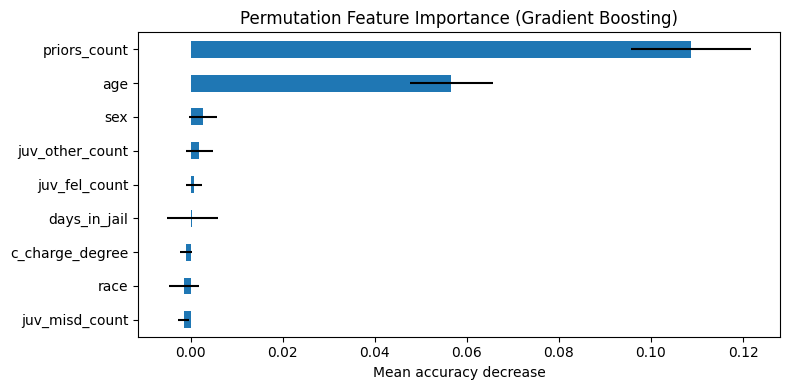

In [18]:
# sklearn does this for all features, repeated multiple times
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(gbm, X_test, y_test, n_repeats=20, random_state=42)

imp = pd.DataFrame({"mean": perm_imp.importances_mean, "std": perm_imp.importances_std},
                    index=feature_names).sort_values("mean")

fig, ax = plt.subplots(figsize=(8, 4))
imp["mean"].plot.barh(xerr=imp["std"], ax=ax)
ax.set_title("Permutation Feature Importance (Gradient Boosting)")
ax.set_xlabel("Mean accuracy decrease")
plt.tight_layout()
plt.show()

## 3. Partial dependence plots -- marginal effect of features, 1D + 2D interaction

Person: {'age': np.int64(27), 'sex': np.int64(1), 'race': np.int64(5), 'juv_fel_count': np.int64(0), 'juv_misd_count': np.int64(0), 'juv_other_count': np.int64(0), 'priors_count': np.int64(0), 'c_charge_degree': np.int64(1), 'days_in_jail': np.int64(1)}



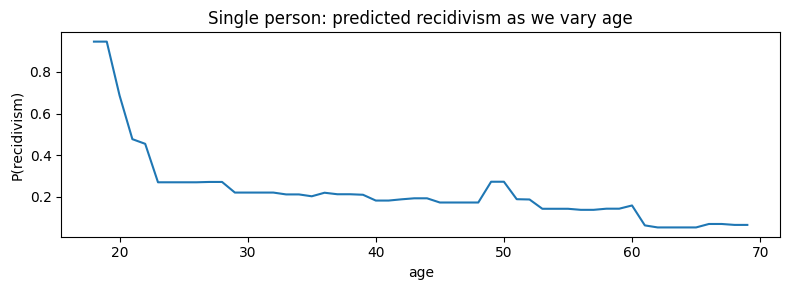

In [19]:
# For one person: what does the model predict if we vary their age?
person = X_test.iloc[0].copy()
print("Person:", dict(person))
print()

ages = range(18, 70)
probs = []
for a in ages:
    person_modified = person.copy()
    person_modified["age"] = a
    prob = gbm.predict_proba(person_modified.values.reshape(1, -1))[0, 1]
    probs.append(prob)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(list(ages), probs)
ax.set_xlabel("age")
ax.set_ylabel("P(recidivism)")
ax.set_title("Single person: predicted recidivism as we vary age")
plt.tight_layout()
plt.show()

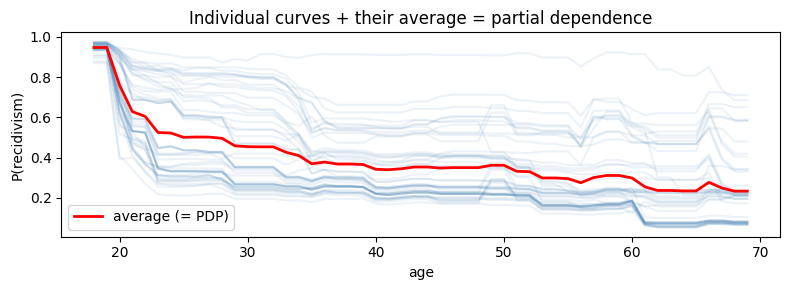

In [20]:
# PDP = average this curve over many people
sample = X_test.sample(50, random_state=42)
ages = range(18, 70)

fig, ax = plt.subplots(figsize=(8, 3))
all_probs = []
for _, person in sample.iterrows():
    probs = []
    for a in ages:
        p = person.copy()
        p["age"] = a
        probs.append(gbm.predict_proba(p.values.reshape(1, -1))[0, 1])
    all_probs.append(probs)
    ax.plot(list(ages), probs, color="steelblue", alpha=0.1)

# The average is the partial dependence
avg = np.mean(all_probs, axis=0)
ax.plot(list(ages), avg, color="red", linewidth=2, label="average (= PDP)")
ax.set_xlabel("age")
ax.set_ylabel("P(recidivism)")
ax.set_title("Individual curves + their average = partial dependence")
ax.legend()
plt.tight_layout()
plt.show()

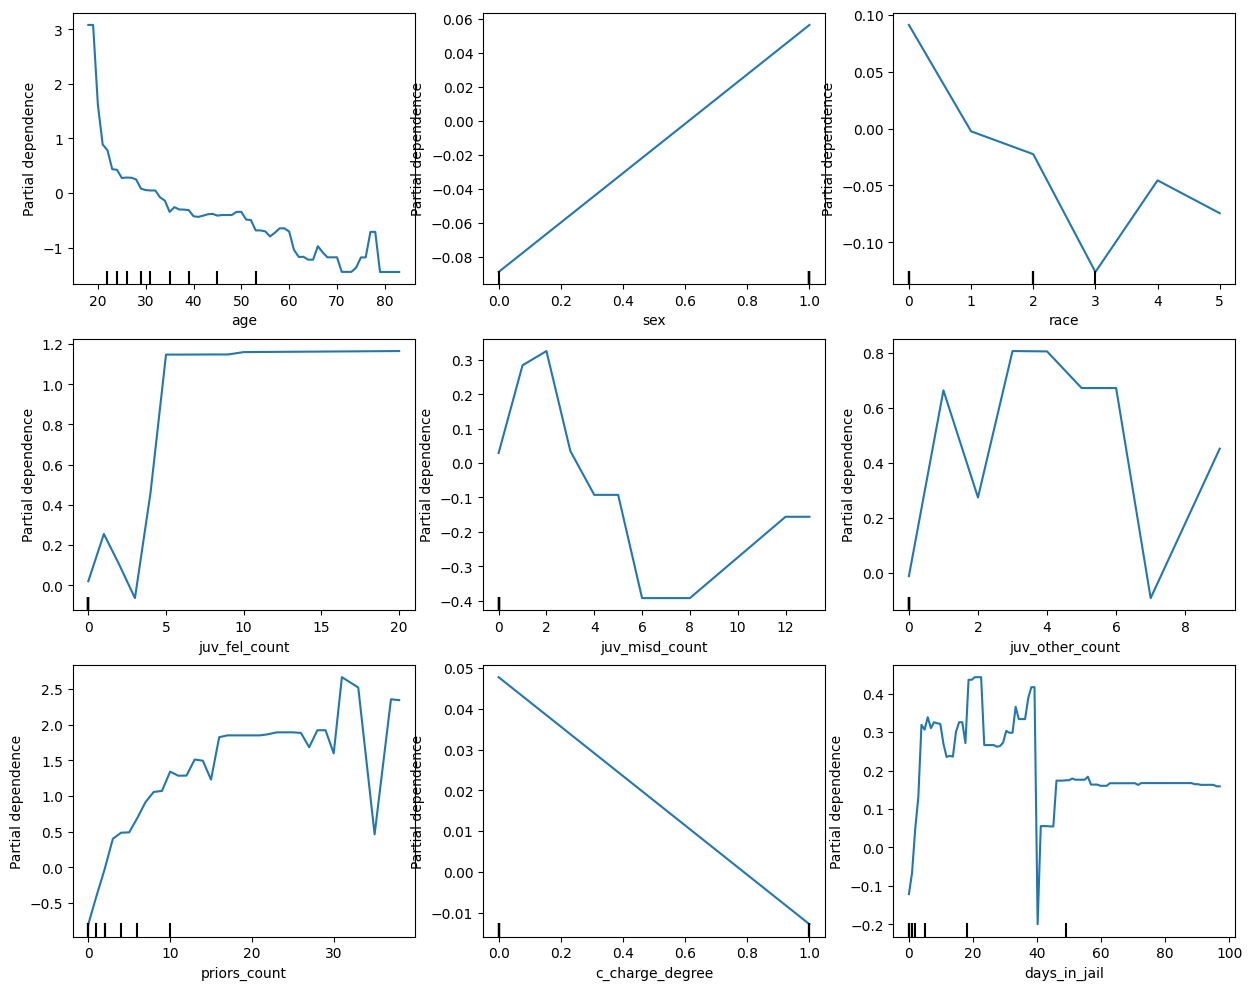

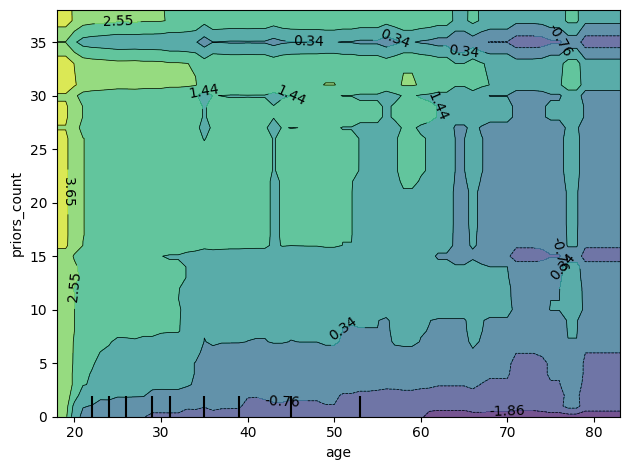

In [21]:
from sklearn.inspection import PartialDependenceDisplay

n_features = len(feature_names)
ncols = 3
nrows = (n_features + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()

for i, feat in enumerate(feature_names):
    PartialDependenceDisplay.from_estimator(gbm, X_train, features=[feat], ax=axes_flat[i],
                                            feature_names=feature_names)


# 2D PDP for age x priors_count interaction
PartialDependenceDisplay.from_estimator(gbm, X_train, features=[("age", "priors_count")], 
                                        feature_names=feature_names)

plt.tight_layout()
plt.show()

## 4. LIME -- local linear surrogate on perturbed neighbors, two examples (recid vs not)

In [36]:
# === Pick a person to explain ===
# All LIME, SHAP, counterfactual, and prototype cells below use this.
# Re-run from here to change the person.

# Option 1: random person from test set
person = X_test.sample(1).iloc[0].copy()

# Option 2: pick by index
# person = X_test.iloc[0].copy()

# Option 3: override specific values
person["age"] = 72
person["priors_count"] = 12

print("Person to explain:")
print(person.to_frame().T.to_string(index=False))
print(f"\nGBM prediction: {'Recidivism' if gbm.predict(person.values.reshape(1,-1))[0] == 1 else 'No Recidivism'}")
print(f"P(recidivism):  {gbm.predict_proba(person.values.reshape(1,-1))[0,1]:.3f}")

Person to explain:
 age  sex  race  juv_fel_count  juv_misd_count  juv_other_count  priors_count  c_charge_degree  days_in_jail
  72    1     3              0               0                0            12                0           141

GBM prediction: No Recidivism
P(recidivism):  0.450


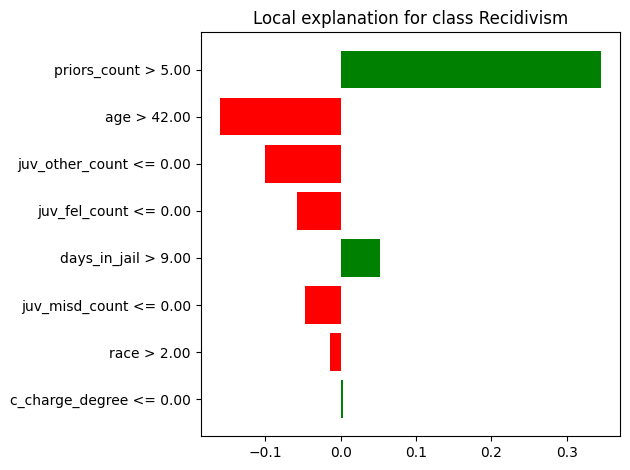

In [38]:
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=feature_names,
    class_names=["No Recidivism", "Recidivism"], mode="classification"
)

exp1 = explainer.explain_instance(person.values, gbm.predict_proba, num_features=8)
exp1.as_pyplot_figure()
plt.tight_layout()
plt.show()

In [41]:
# Illustrating LIME in 2D with just age x priors_count
# Train a 2-feature model so we can visualize the prediction surface
gbm2d = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gbm2d.fit(X_train[["age", "priors_count"]], y_train)

# Prediction surface for plotting
age_range = np.linspace(X_train["age"].min(), X_train["age"].max(), 80)
prior_range = np.linspace(X_train["priors_count"].min(), X_train["priors_count"].min() + 20, 80)
aa, pp = np.meshgrid(age_range, prior_range)
grid = pd.DataFrame({"age": aa.ravel(), "priors_count": pp.ravel()})
zz = gbm2d.predict_proba(grid)[:, 1].reshape(aa.shape)

person_age = person["age"]
person_priors = person["priors_count"]

# LIME step by step:
# 1. Sample perturbed points from the training distribution
# 2. Get black-box predictions for them
# 3. Weight by proximity (LIME scales features first, then uses exponential kernel)
# 4. Fit a weighted linear model -- the local explanation
from sklearn.linear_model import Ridge

n_samples = 500
perturbed = X_train[["age", "priors_count"]].sample(n_samples, replace=True, random_state=42).values
perturbed_preds = gbm2d.predict_proba(perturbed)[:, 1]

# Scale features before computing distances (like LIME does internally)
scaler2d = StandardScaler()
scaler2d.fit(X_train[["age", "priors_count"]])
perturbed_scaled = scaler2d.transform(perturbed)
instance_scaled = scaler2d.transform([[person_age, person_priors]])

dists = np.sqrt(((perturbed_scaled - instance_scaled) ** 2).sum(axis=1))
# LIME's default kernel width: sqrt(n_features) * 0.75
kernel_width = np.sqrt(2) * 0.75
weights = np.exp(-(dists ** 2) / (kernel_width ** 2))

lime_local = Ridge(alpha=1.0)
lime_local.fit(perturbed, perturbed_preds, sample_weight=weights)

print(f"Local linear approximation around (age={person_age:.0f}, priors={person_priors:.0f}):")
print(f"  P(recid) ~ {lime_local.intercept_:.3f} + {lime_local.coef_[0]:.4f}*age + {lime_local.coef_[1]:.4f}*priors_count")
print(f"  -> age pushes {'toward' if lime_local.coef_[0] > 0 else 'away from'} recidivism")
print(f"  -> priors pushes {'toward' if lime_local.coef_[1] > 0 else 'away from'} recidivism")

Local linear approximation around (age=72, priors=12):
  P(recid) ~ 0.362 + -0.0012*age + 0.0326*priors_count
  -> age pushes away from recidivism
  -> priors pushes toward recidivism


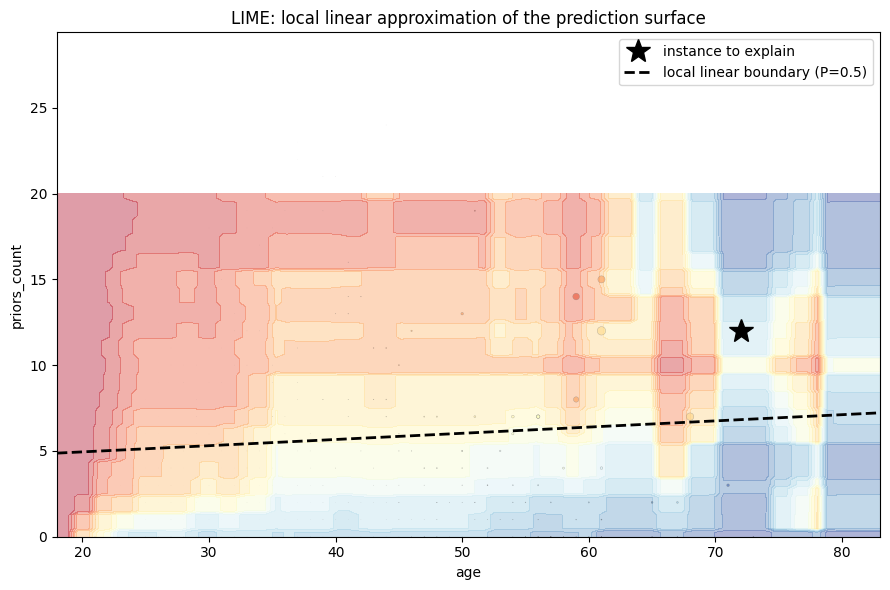

In [42]:
# Visualize: prediction surface + perturbed samples (sized by weight) + local linear decision boundary
fig, ax = plt.subplots(figsize=(9, 6))

# Prediction surface
ax.contourf(aa, pp, zz, levels=20, cmap="RdYlBu_r", alpha=0.4)

# Perturbed points, size proportional to weight
ax.scatter(perturbed[:, 0], perturbed[:, 1], c=perturbed_preds, cmap="RdYlBu_r",
           s=weights * 80, edgecolors="gray", linewidths=0.3, alpha=0.6)

# The instance
ax.plot(person_age, person_priors, "k*", markersize=18, zorder=5, label="instance to explain")

# Local linear model's decision boundary (where P=0.5)
# lime_local.intercept_ + coef[0]*age + coef[1]*priors = 0.5
if abs(lime_local.coef_[1]) > 1e-6:
    age_line = np.linspace(aa.min(), aa.max(), 100)
    priors_line = (0.5 - lime_local.intercept_ - lime_local.coef_[0] * age_line) / lime_local.coef_[1]
    mask = (priors_line >= pp.min()) & (priors_line <= pp.max())
    ax.plot(age_line[mask], priors_line[mask], "k--", linewidth=2, label="local linear boundary (P=0.5)")

ax.set_xlabel("age")
ax.set_ylabel("priors_count")
ax.set_title("LIME: local linear approximation of the prediction surface")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 5. SHAP -- Shapley values for the same person, then how it works in 2D, then global views

SHAP explanation for selected person:


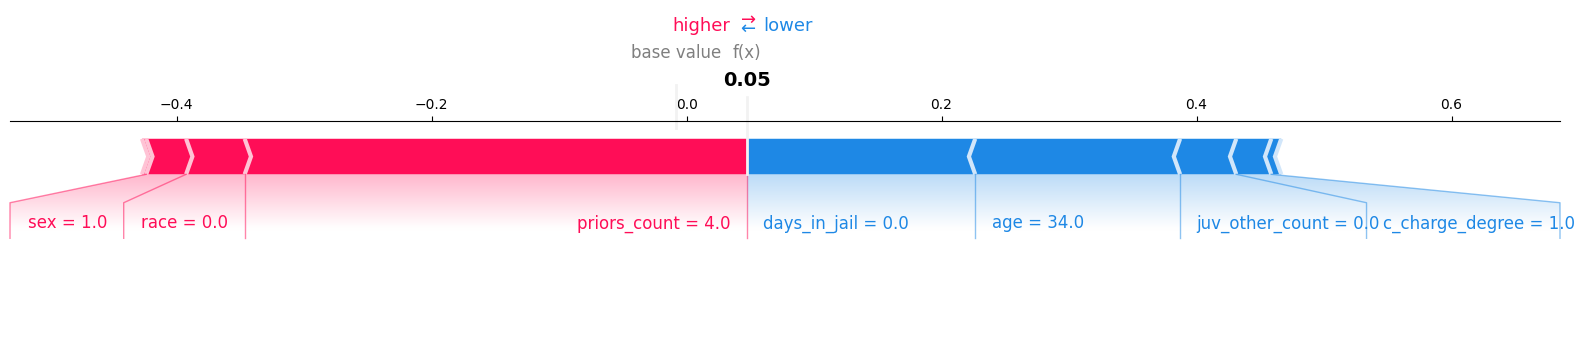

In [26]:
import shap

# Force plot for the same person we used in LIME
shap_explainer = shap.TreeExplainer(gbm)
shap.initjs()
person_shap = shap_explainer.shap_values(person.values.reshape(1, -1))[0]
print("SHAP explanation for selected person:")
shap.force_plot(shap_explainer.expected_value, person_shap,
                person, feature_names=feature_names, matplotlib=True)
plt.show()

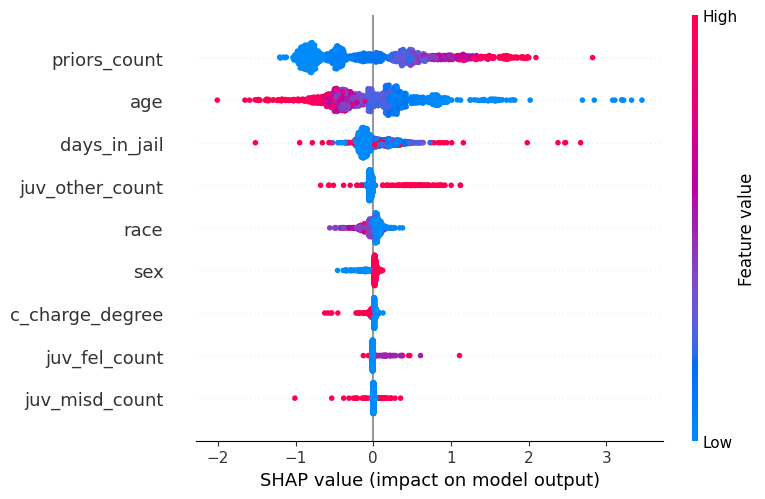

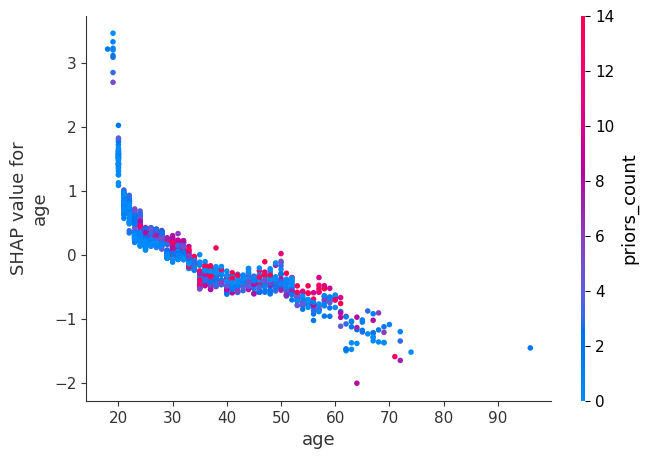

In [27]:
# Global SHAP views (for reference -- these explain the model, not one person)
shap_values = shap_explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=feature_names)

shap.dependence_plot("age", shap_values, X_test, feature_names=feature_names,
                     interaction_index="priors_count")

## 6. Counterfactuals -- smallest change to flip prediction, via DiCE

In [28]:
import dice_ml

# Prepare data and model for DiCE
train_df = X_train.copy()
train_df["is_recid"] = y_train.values

dice_data = dice_ml.Data(dataframe=train_df, continuous_features=feature_names, outcome_name="is_recid")
dice_model = dice_ml.Model(model=gbm, backend="sklearn")

dice_exp = dice_ml.Dice(dice_data, dice_model, method="random")

# Generate counterfactuals for the same person we explained with LIME and SHAP
query = person.to_frame().T
pred = gbm.predict(query)[0]
prob = gbm.predict_proba(query)[0, 1]
pred_label = "Recidivism" if pred == 1 else "No Recidivism"
desired = "No Recidivism" if pred == 1 else "Recidivism"

print("=== Same person as LIME / SHAP ===")
print(query.to_string(index=False))
print(f"Current prediction: {pred_label} (P(recidivism) = {prob:.3f})")
print(f"\nQuestion: What is the smallest change that would flip the prediction to '{desired}'?\n")

cf = dice_exp.generate_counterfactuals(query, total_CFs=3, desired_class="opposite")
cf.visualize_as_dataframe(show_only_changes=True)

=== Same person as LIME / SHAP ===
 age  sex  race  juv_fel_count  juv_misd_count  juv_other_count  priors_count  c_charge_degree  days_in_jail
  34    1     0              0               0                0             4                1             0
Current prediction: Recidivism (P(recidivism) = 0.512)

Question: What is the smallest change that would flip the prediction to 'No Recidivism'?



100%|██████████| 1/1 [00:00<00:00,  5.02it/s]

Query instance (original outcome : 1)


,age,sex,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,days_in_jail,is_recid
0,34,1,0,0,0,0,4,1,0,1



Diverse Counterfactual set (new outcome: 0)


,age,sex,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,days_in_jail,is_recid
0,-,-,-,-,4,-,-,0,-,0
1,-,0,-,-,11,-,-,-,-,0
2,-,0,-,-,-,-,-,0,-,0


## 7. Prototypes -- k-NN: "similar past cases" as explanation

In [29]:
from sklearn.neighbors import NearestNeighbors

# Fit k-NN on scaled training data
nn = NearestNeighbors(n_neighbors=5, metric="euclidean")
nn.fit(X_train_scaled)

# Find prototypes for the selected person
query_scaled = scaler.transform(person.values.reshape(1, -1))
distances, indices = nn.kneighbors(query_scaled)

print("Query instance:")
print(person.to_frame().T.to_string(index=False))
print(f"Model prediction: {'Recidivism' if gbm.predict(person.values.reshape(1,-1))[0] == 1 else 'No Recidivism'}")
print()

prototypes = X_train.iloc[indices[0]].copy()
prototypes["actual_recid"] = y_train.iloc[indices[0]].values
prototypes["distance"] = distances[0]
print("5 most similar training instances (prototypes):")
prototypes

Query instance:
 age  sex  race  juv_fel_count  juv_misd_count  juv_other_count  priors_count  c_charge_degree  days_in_jail
  34    1     0              0               0                0             4                1             0
Model prediction: Recidivism

5 most similar training instances (prototypes):


,age,sex,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,days_in_jail,actual_recid,distance
5323,34,1,0,0,0,0,4,1,0,0,0.000000
838,34,1,0,0,0,0,4,1,1,0,0.019198
2527,35,1,0,0,0,0,4,1,1,0,0.087281
1116,33,1,0,0,0,0,4,1,1,1,0.087281
4042,35,1,0,0,0,0,4,1,6,0,0.143239


## 8. Prototypes & Criticisms -- representative examples and outliers to spot data problems

**Prototypes** are the most representative examples of each cluster/class — they summarize what "typical" cases look like.

**Criticisms** are the instances that are *poorly* represented by the prototypes — outliers or edge cases that don't fit the typical patterns. These are especially useful for spotting potential data quality issues, unusual subpopulations, or cases the model might struggle with.

In [30]:
from sklearn.cluster import KMeans

# Use KMeans to find cluster structure, then pick prototypes (closest to center)
# and criticisms (farthest from any center)
n_clusters = 4
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = km.fit_predict(X_train_scaled)

# --- Prototypes: training point closest to each cluster center ---
prototypes_idx = []
for c in range(n_clusters):
    mask = np.where(clusters == c)[0]
    dists = np.linalg.norm(X_train_scaled[mask] - km.cluster_centers_[c], axis=1)
    prototypes_idx.append(mask[np.argmin(dists)])

proto_df = X_train.iloc[prototypes_idx].copy()
proto_df["actual_recid"] = y_train.iloc[prototypes_idx].values
proto_df["cluster"] = range(n_clusters)
print("=== Prototypes (most representative person per cluster) ===")
print(proto_df.to_string())

# --- Criticisms: training points farthest from their nearest cluster center ---
all_dists = np.min(km.transform(X_train_scaled), axis=1)  # dist to nearest center
n_criticisms = 5
crit_idx = np.argsort(all_dists)[-n_criticisms:][::-1]

crit_df = X_train.iloc[crit_idx].copy()
crit_df["actual_recid"] = y_train.iloc[crit_idx].values
crit_df["dist_to_center"] = all_dists[crit_idx]
print("\n=== Criticisms (most unusual people — farthest from any cluster center) ===")
print(crit_df.to_string())
print("\nThese outliers may indicate data entry errors, rare subpopulations, or edge cases worth investigating.")

=== Prototypes (most representative person per cluster) ===
      age  sex  race  juv_fel_count  juv_misd_count  juv_other_count  priors_count  c_charge_degree  days_in_jail  actual_recid  cluster
5416   34    0     1              0               0                0             1                0             2             0        0
1291   38    1     1              0               0                0             2                0             8             0        1
5956   37    1     2              0               0                0             2                1            12             0        2
5251   31    1     0              1               1                1            13                0             1             1        3

=== Criticisms (most unusual people — farthest from any cluster center) ===
      age  sex  race  juv_fel_count  juv_misd_count  juv_other_count  priors_count  c_charge_degree  days_in_jail  actual_recid  dist_to_center
1794   25    1     5             2

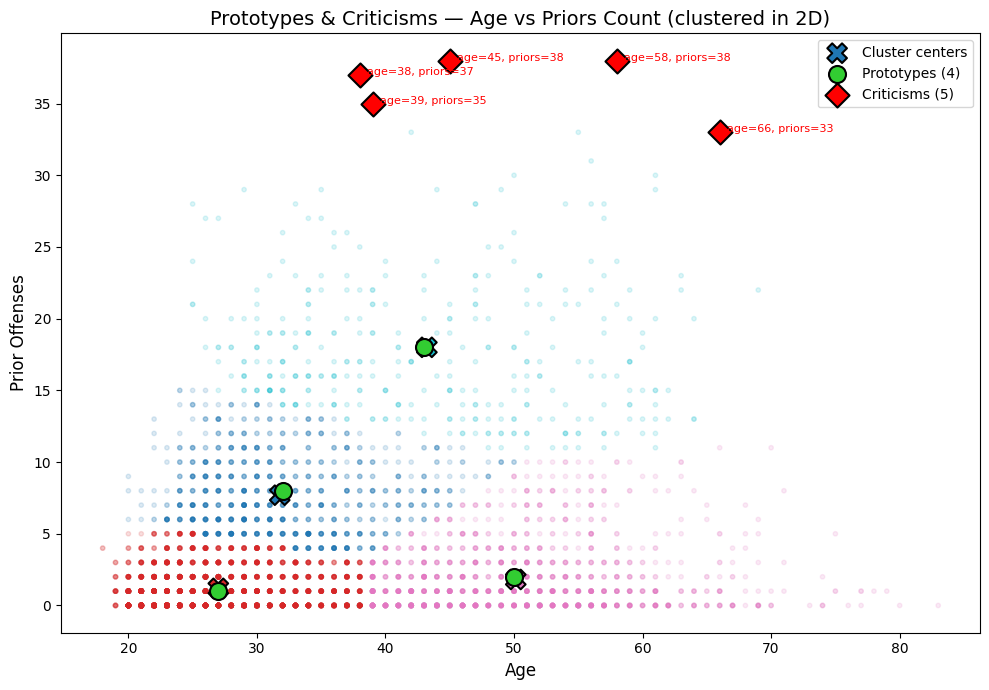

Green circles = prototypes (typical cases). Red diamonds = criticisms (outliers).
Criticisms far from any cluster are candidates for data quality review.


In [31]:
# 2D visualization: cluster on just age & priors_count so clusters are meaningful in the plot
from sklearn.preprocessing import StandardScaler as SS2

X_2d = X_train[["age", "priors_count"]].values
scaler_2d = SS2().fit(X_2d)
X_2d_scaled = scaler_2d.transform(X_2d)

km_2d = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters_2d = km_2d.fit_predict(X_2d_scaled)

# Prototypes & criticisms in 2D
proto_2d_idx = []
for c in range(n_clusters):
    mask = np.where(clusters_2d == c)[0]
    dists = np.linalg.norm(X_2d_scaled[mask] - km_2d.cluster_centers_[c], axis=1)
    proto_2d_idx.append(mask[np.argmin(dists)])

all_dists_2d = np.min(km_2d.transform(X_2d_scaled), axis=1)
crit_2d_idx = np.argsort(all_dists_2d)[-n_criticisms:][::-1]

centers_2d = scaler_2d.inverse_transform(km_2d.cluster_centers_)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(X_train["age"], X_train["priors_count"],
           c=clusters_2d, cmap="tab10", alpha=0.15, s=10, label="_nolegend_")

ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
           c=range(n_clusters), cmap="tab10", s=200, marker="X",
           edgecolors="black", linewidths=1.5, zorder=5, label="Cluster centers")

ax.scatter(X_train.iloc[proto_2d_idx]["age"], X_train.iloc[proto_2d_idx]["priors_count"],
           c="limegreen", s=150, marker="o", edgecolors="black", linewidths=1.5,
           zorder=6, label=f"Prototypes ({n_clusters})")

ax.scatter(X_train.iloc[crit_2d_idx]["age"], X_train.iloc[crit_2d_idx]["priors_count"],
           c="red", s=150, marker="D", edgecolors="black", linewidths=1.5,
           zorder=6, label=f"Criticisms ({n_criticisms})")

for idx in crit_2d_idx:
    ax.annotate(f"  age={X_train.iloc[idx]['age']:.0f}, priors={X_train.iloc[idx]['priors_count']:.0f}",
                (X_train.iloc[idx]["age"], X_train.iloc[idx]["priors_count"]),
                fontsize=8, color="red", zorder=7)

ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Prior Offenses", fontsize=12)
ax.set_title("Prototypes & Criticisms — Age vs Priors Count (clustered in 2D)", fontsize=14)
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

print("Green circles = prototypes (typical cases). Red diamonds = criticisms (outliers).")
print("Criticisms far from any cluster are candidates for data quality review.")